**Import statements**

In [1]:
import mne
import numpy as np
import pandas as pd
import pylab as plt
import os
import sys
import pickle as pk
from glob import glob
import re
import multiprocess as mp
from scipy.stats import zscore, ttest_ind, ttest_1samp

sys.path.insert(0, '../lib/')  # add path to custom library

root = '../../data/'  # provide subject directory name, and edit file root as needed
subject_ids = ['S25_245', 'S23_214', 'S25_248', 'S25_247', 'S24_218', 'S23_211',
              'S23_212', 'S24_219', 'S24_221', 'S24_222', 'S24_229', 'S24_237', 'S24_236',
              'S25_258', 'S25_120c', 'S25_255', 'S25_252', 'S24_220', 'S26_263', 'S26_264']

# Load some sample data to get data object information
subject = 'S25_245'
fn_prefix = f'../../derivatives/pulse_labels/{subject}'
epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
epochs_trigger = epochs_trigger.crop(tmin=-1, tmax=2.3) 

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/1170555198.py:23: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/1170555198.py:23: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)


**Helper functions**

In [2]:
import copy

def exclude_target_lead(spec_tbs):
    import re
    
    # Find stim target index
    channels = [s.upper() for s in spec_tbs.ch_names]
    m = spec_tbs.metadata
    try:
        stim_index = channels.index(m.iloc[0]['stim_target'].upper())
    except ValueError:
        print('Stim channel already removed')
        pass
    
    # Find all channels on stim lead
    target_lead = re.findall(r'[a-zA-Z]', m.iloc[0]['stim_target'].split('-')[0])
    target_lead = "".join(target_lead)

    target_channels = []; target_idxs = []
    for idx, c in enumerate(channels):
        letters = re.findall(r'[a-zA-Z]', c.split('-')[0])
        letters = "".join(letters)
    
        if letters.upper() in target_lead.upper():
            target_channels.append(c)
            target_idxs.append(idx)

    return list(np.array(spec_tbs.ch_names)[target_idxs]), target_idxs
    
def zscore_epoch(data, times, baseline=(-0.2, 0)):
    """
    Individually z-scores a single channel/trial against its own baseline.
    No variance is pooled across other channels or trials.
    """
    tmin, tmax = baseline
    # Create a mask for the baseline period
    mask = (times >= tmin) & (times <= tmax)
    
    # Calculate stats ONLY for this specific channel-trial segment
    mu = np.mean(data[mask])
    sigma = np.std(data[mask])
    
    # Standardize the entire trial using its local baseline stats
    # 1e-12 prevents division by zero if a channel is flat/dead
    return (data - mu) / (sigma + 1e-12)

def rank_channels_by_ptp(evoked, tmin_win=0.05, tmax_win=0.3, n_top=10, n_bottom=10):
    """
    Calculates Peak-to-Peak (PTP) amplitude for an evoked object within a 
    specific window and returns ranked channel lists and the full DataFrame.
    """
    # 1. Crop a copy to the window of interest
    evoked_win = evoked.copy().crop(tmin=tmin_win, tmax=tmax_win)

    # 2. Calculate PTP across the time axis (axis=1)
    ptp_data = np.ptp(evoked_win.data, axis=1)

    # 3. Create and sort the DataFrame
    df_ptp = pd.DataFrame({
        'channel': evoked.ch_names,
        'ptp_value': ptp_data
    }).sort_values(by='ptp_value', ascending=False)

    # 4. Extract top and bottom channel lists
    top_chans = df_ptp['channel'].head(n_top).tolist()
    bottom_chans = df_ptp['channel'].tail(n_bottom).tolist()

    return df_ptp, top_chans, bottom_chans

def reject_outlier_epochs(epochs_ccep_pre, epochs_ccep_post, count_cutoff=7, outlier_threshold=5):

    # Find outlier epochs
    pre_copy = epochs_ccep_pre.copy()  #.drop_channels(epochs_ccep_pre.info['bads'])
    post_copy = epochs_ccep_post.copy()  #.drop_channels(epochs_ccep_post.info['bads'])
    eeg_pre = pre_copy.crop(tmin=0.1, tmax=2.3).get_data()  
    eeg_post = post_copy.crop(tmin=0.1, tmax=2.3).get_data()
    bad_epochs_pre = [np.unique(np.where(np.abs(zscore(eeg_pre[:, cidx, :], axis=None))>outlier_threshold)[0]) for cidx in range(eeg_pre.shape[1])]
    bad_epochs_post = [np.unique(np.where(np.abs(zscore(eeg_post[:, cidx, :], axis=None))>outlier_threshold)[0]) for cidx in range(eeg_post.shape[1])]

    # Drop channels with too many bad epochs   
    channels = [s for s in pre_copy.ch_names]
    bad_epoch_count_pre = [len(i) for i in bad_epochs_pre]
    bad_epoch_count_post = [len(i) for i in bad_epochs_post]
    reject_channels = np.unique(list(np.array(channels)[np.array(bad_epoch_count_pre)>count_cutoff])+
                      list(np.array(channels)[np.array(bad_epoch_count_post)>count_cutoff]))
    reject_channels = list(reject_channels); reject_idx = [channels.index(i) for i in reject_channels]

    return bad_epochs_pre, bad_epochs_post, reject_channels

### Analyze spectral response for a given individual subject
Example pipeline to process and analyze spectral activity in a single subject. Used to generate panels in Figure 1. 

**1. Extract spectral power and CCEPs for all epochs**

In [10]:
import numpy as np
import pandas as pd
import re
from scipy.stats import zscore

params = {
    'method': 'multitaper', #'n_cycles': 4,
    'n_cycles': [2, 2, 2, 2, 2, 
             2.5, 2.5, 2.5, 2.5, 2.5, 
             3, 3, 3, 3, 3,
             3.5, 3.5, 3.5, 3.5, 3.5,
             4, 4, 4, 4, 4,
             5, 5, 5, 5, 5, 
             6, 6, 6, 6, 6],
    'spectral_baseline_start': -0.6,
    'spectral_baseline_end': -0.1,
    'freq_range': np.logspace(np.log10(4), np.log10(180), 35),
    'outlier_threshold': 5,
    'intensity': 'High'
}

# Windowing params for saving
win_dur, win_step = 0.2, 0.05         
tmin_plot, tmax_plot = -0.5, 2.0
win_starts = np.arange(tmin_plot, tmax_plot - win_dur, win_step)
tfr_times = epochs_trigger.times

for subject in ['S23_211']:
    
    # Load Data
    fn_prefix = f'../../derivatives/pulse_labels/{subject}'
    epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
    epochs_trigger = epochs_trigger.crop(tmin=-1, tmax=2.3)                         # to ensure uniform time windows across all subjects
    
    results_list = []
    
    for tbs_block in ['iTBS1', 'iTBS2', 'iTBS3']:
    
        # Filter Intensity
        if params['intensity'] == 'High':
            epochs_trigger = epochs_trigger['~(block.str.contains("Low"))'].pick_types(seeg=True, exclude=[])
        elif params['intensity'] == 'Low':
            epochs_trigger = epochs_trigger['~(block.str.contains("High"))'].pick_types(seeg=True, exclude=[])
        else:
            epochs_trigger = epochs_trigger.pick_types(seeg=True, exclude=[])
        
        # Get events metadata
        meta = epochs_trigger.metadata
        all_targets = meta['stim_target'].unique()
        m_block = meta[meta['block'] == tbs_block]
        
        for targ in all_targets:
            m = m_block[m_block['stim_target'] == targ]
            if len(m) == 0: 
                print('***No events found for this target/block combination***')
                continue
        
            # Get single-pulse (CCEP) data
            pre_q =  f'(block.str.contains("Pre{tbs_block}") & (stim_target.str.contains("{targ}")))'
            post_q = f'(block.str.contains("Post{tbs_block}") & (stim_target.str.contains("{targ}")))'
            baseline_q = f'(block.str.contains("PreiTBS1|Baseline") & (stim_target.str.contains("{targ}")))'    
            epochs_ccep_pre = epochs_trigger[pre_q]
            epochs_ccep_post = epochs_trigger[post_q]
            epochs_ccep_baseline = epochs_trigger[baseline_q]

            # Check to see if we have data for this block/target
            if len(epochs_ccep_pre)==0:
                print('***No events found for this target/block combination***')
                continue
        
            # Identify target lead
            target_chans, target_idxs = exclude_target_lead(epochs_ccep_pre)
        
            # Reject outlier epochs and channels
            bad_epochs_pre, bad_epochs_post, reject_channels = reject_outlier_epochs(epochs_ccep_pre, epochs_ccep_post, outlier_threshold=params['outlier_threshold'])
            bad_epochs_dict = {'bad_epochs_pre': bad_epochs_pre, 'bad_epochs_post': bad_epochs_post}
            epochs_ccep_pre.info['bads'] += reject_channels
            epochs_ccep_post.info['bads'] += reject_channels
            epochs_ccep_baseline.info['bads'] += reject_channels
        
            results = {'subject': subject, 'block': tbs_block, 'target': targ}
    
            # Rank top channels by z-scored CCEP
            epochs_z_baseline = epochs_ccep_baseline.copy().apply_function(zscore_epoch, times=epochs_ccep_baseline.times, baseline=(-0.2, 0)).average()
            df_ptp, _, _ = rank_channels_by_ptp(epochs_z_baseline, n_top=10, n_bottom=10)
            top_chans = df_ptp[df_ptp['ptp_value']>3]['channel'].tolist()
            bottom_chans = df_ptp['channel'].tail(len(top_chans)).tolist()
            if len(top_chans)<0:
                print('***No significant CCEPs found!***: '+subject+', '+targ+', '+tbs_block)
                continue
            
            for cond, subset in [('pre', epochs_ccep_pre), ('post', epochs_ccep_post)]:
        
                # Get CCEPs
                epochs_z = subset.copy().apply_function(zscore_epoch, times=subset.times, baseline=(-0.2, 0))
                evoked_z = epochs_z.average()
                
                # Compute time-frequency representation
                tfr = subset.compute_tfr(method=params['method'], freqs=params['freq_range'],
                                 n_cycles=params['n_cycles'], picks=subset.ch_names, verbose=False)
                
                # Baseline correct (doing this manually, as MNE's baseline correct behavior is not easy to understand)
                bs = tfr.copy().crop(tmin=params['spectral_baseline_start'], tmax=params['spectral_baseline_end'])
                bs_avg_time = np.nanmean(np.log10(bs.data), axis=3)
                subtract_array = np.tile(bs_avg_time[..., np.newaxis], (1, 1, 1, tfr.data.shape[3]))
                tfr_corrected = np.log10(tfr.data)-subtract_array
        
                # Remove outlier events
                bad_epochs = bad_epochs_dict['bad_epochs_'+cond]
                for idx, epoch_id in enumerate(bad_epochs):
                    tfr_corrected[epoch_id, idx, :, :] = np.nan 

                # Window the data across time dimension for better averaging and such
                tfr_times = tfr.times
                win_starts = np.arange(tmin_plot, tmax_plot - win_dur, win_step)
                win_centers = win_starts + (win_dur / 2)
                
                def get_win_data(raw):
                    out = np.zeros((raw.shape[0], raw.shape[1], len(params['freq_range']), len(win_starts)))
                    for w_idx, start in enumerate(win_starts):
                        t_m = (tfr_times >= start) & (tfr_times < start + win_dur)
                        out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
                    return out
                
                tfr_win = get_win_data(tfr_corrected)
        
                # Save results
                results[f'{cond}_tfr'] = tfr_corrected  # average over frequencies due to memory issues
                results[f'{cond}_ccep'] = evoked_z
                results['lead_channels'] = target_chans
                results['channels'] = tfr.ch_names
                results['top_chans'] = top_chans
                results['bottom_chans'] = bottom_chans
                results['bad_chans'] = reject_channels  # newly-identified bad channels based on epoch exclusions
                results['ptp_baseline'] = df_ptp

            results_list.append(results)
        tfr_df = pd.DataFrame(results_list)

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/2657422038.py:32: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/2657422038.py:32: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/2657422038.py:122: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/2657422038.py:122: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)


***No events found for this target/block combination***
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/2657422038.py:122: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/2657422038.py:122: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)


***No events found for this target/block combination***
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/2657422038.py:122: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/2657422038.py:122: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)


***No events found for this target/block combination***


**2. Rewindow data and, if desired, run resampling test to check for channel-level pre/post changes**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# --- SETTINGS ---
target_subject = subject
stim_target = 0
target_channel = tfr_df.iloc[stim_target]['top_chans'][1] 
blocks = ['iTBS1', 'iTBS2', 'iTBS3']

# Toggle native vs windowed
use_sliding_window = False  # Set to False to keep native time resolution

win_dur, win_step = 0.002, 0.002         
tmin_plot, tmax_plot = -1.0, 2.0
freq_range = params['freq_range']
avg_freq_range = (75, 180) 
aspect_ratio = 0.02 

# A permutation test can be done to find significant clusters, though this is not used in the manuscript itself
n_permutations = 500
p_threshold = 0.001     

# ----------------

def run_trial_permutation(trial_data, n_perms=1):
    n_trials, n_f, n_w = trial_data.shape
    if n_trials < 2: return np.zeros((n_f, n_w)), np.ones((n_f, n_w))
    
    obs_t, _ = stats.ttest_1samp(trial_data, 0, axis=0, nan_policy='omit')
    count_t = np.zeros(obs_t.shape)
    for _ in range(n_perms):
        signs = np.random.choice([-1, 1], size=(n_trials, 1, 1))
        perm_t, _ = stats.ttest_1samp(trial_data * signs, 0, axis=0, nan_policy='omit')
        count_t += (np.abs(perm_t) >= np.abs(obs_t))
        
    return obs_t, (count_t / n_perms)

# 1. Metadata Setup
sample_row = tfr_df.iloc[0]
n_times_tfr = sample_row['pre_tfr'].shape[-1]
tfr_times = np.linspace(-1.0, 2.3, n_times_tfr) 

# Prep time vectors for both modes
if use_sliding_window:
    win_starts = np.arange(tmin_plot, tmax_plot - win_dur, win_step)
    plot_times = win_starts + (win_dur / 2)
else:
    native_t_mask = (tfr_times >= tmin_plot) & (tfr_times <= tmax_plot)
    plot_times = tfr_times[native_t_mask]

avg_win_side = (0.5, 1.0) 
side_mask = (plot_times >= avg_win_side[0]) & (plot_times <= avg_win_side[1])
freq_mask = (freq_range >= avg_freq_range[0]) & (freq_range <= avg_freq_range[1])

# 2. Data Processing Pass
processed = {}
global_lims = {'ccep': [0, 0], 'tfr': 0, 'diff': 0, 'tc': [0, 0]}

for block in blocks:
    sub_df = tfr_df[(tfr_df['subject'] == target_subject) & (tfr_df['block'] == block)]
    if sub_df.empty: continue
    row = sub_df.iloc[stim_target]
    
    # --- A. Channel Selection ---
    if target_channel:
        ch_idx = list(row['channels']).index(target_channel)
        pre_raw = row['pre_tfr'][:, ch_idx, :, :].copy()   
        post_raw = row['post_tfr'][:, ch_idx, :, :].copy() 
    else:
        pre_raw = np.nanmean(row['pre_tfr'], axis=1)
        post_raw = np.nanmean(row['post_tfr'], axis=1)

    # --- B. Data Extraction (Windowed vs Native) ---
    if use_sliding_window:
        def get_win_data(raw):
            out = np.zeros((raw.shape[0], len(freq_range), len(win_starts)))
            for w_idx, start in enumerate(win_starts):
                t_m = (tfr_times >= start) & (tfr_times < start + win_dur)
                out[:, :, w_idx] = np.nanmean(raw[:, :, t_m], axis=2)
            return out
        pre_trials = get_win_data(pre_raw)
        post_trials = get_win_data(post_raw) 
    else:
        # Just slice the native resolution
        pre_trials = pre_raw[:, :, native_t_mask]
        post_trials = post_raw[:, :, native_t_mask]

    trial_pre_win = np.nanmean(pre_trials[:, freq_mask, :][:, :, side_mask], axis=(1, 2))
    trial_post_win = np.nanmean(post_trials[:, freq_mask, :][:, :, side_mask], axis=(1, 2))
    
    # --- C. Stats & Averages ---
    mean_pre_map = np.nanmean(pre_trials, axis=0)
    avg_post = np.nanmean(post_trials, axis=0)
    trial_diffs = post_trials - mean_pre_map 
    
    _, p_map = run_trial_permutation(trial_diffs, n_perms=n_permutations)
    
    trial_tc_diff = np.nanmean(trial_diffs[:, freq_mask, :], axis=1)
    _, tc_p = run_trial_permutation(trial_tc_diff[:, np.newaxis, :], n_perms=n_permutations)

    tc_pre, tc_post = np.nanmean(mean_pre_map[freq_mask, :], axis=0), np.nanmean(avg_post[freq_mask, :], axis=0)
    
    # --- D. CCEP Extraction ---
    if target_channel:
        ccep_pre_data = row['pre_ccep'].copy().pick(target_channel).data.flatten()
        ccep_post_data = row['post_ccep'].copy().pick(target_channel).data.flatten()
    else:
        ccep_pre_data = np.nanmean(row['pre_ccep'].data, axis=0)
        ccep_post_data = np.nanmean(row['post_ccep'].data, axis=0)

    # Update Global Scales
    global_lims['tfr'] = max(global_lims['tfr'], np.nanmax(np.abs([mean_pre_map, avg_post])))
    global_lims['diff'] = max(global_lims['diff'], np.nanmax(np.abs(avg_post - mean_pre_map)))
    global_lims['ccep'] = [min(global_lims['ccep'][0], np.nanmin([ccep_pre_data, ccep_post_data])), 
                           max(global_lims['ccep'][1], np.nanmax([ccep_pre_data, ccep_post_data]))]
    global_lims['tc'] = [min(global_lims['tc'][0], np.nanmin([tc_pre, tc_post])), 
                         max(global_lims['tc'][1], np.nanmax([tc_pre, tc_post]))]
    
    processed[block] = {
        'pre_map': mean_pre_map, 'post_map': avg_post, 'p_map': p_map,
        'tc_pre': tc_pre, 'tc_post': tc_post, 'sig_tc': tc_p[0] < p_threshold,
        'ccep_pre': ccep_pre_data, 'ccep_post': ccep_post_data,
        'ccep_t': row['pre_ccep'].times,
        'trials_pre': trial_pre_win,
        'trials_post': trial_post_win
    }


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/1575937992.py:90: RuntimeWarning: Mean of empty slice
  trial_pre_win = np.nanmean(pre_trials[:, freq_mask, :][:, :, side_mask], axis=(1, 2))
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32105/1575937992.py:91: RuntimeWarning: Mean of empty slice
  trial_post_win = np.nanmean(post_trials[:, freq_mask, :][:, :, side_mask], axis=(1, 2))


**3. Plot Results**

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# --- USER UPDATED STYLE ---
mpl.rcParams['axes.linewidth'] = 2.0 
mpl.rcParams['xtick.major.width'] = 2.0
mpl.rcParams['ytick.major.width'] = 2.0
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['ytick.major.size'] = 6

# --- SETTINGS ---
p_threshold = 0.001   
# ----------------

# Plotting
fig = plt.figure(figsize=(24, 22)) 
# Updated height ratios per your change
gs = fig.add_gridspec(6, 3, height_ratios=[1.2, 1, 1, 1, 1, 1], hspace=0.4, wspace=0.3)
v_tfr, v_diff = global_lims['tfr']*0.8, global_lims['diff']*0.8

side_mask = (plot_times >= avg_win_side[0]) & (plot_times <= avg_win_side[1])

for col, block in enumerate(blocks):
    if block not in processed: continue
    d = processed[block]
    
    # --- R0: CCEP ---
    ax0 = fig.add_subplot(gs[0, col])
    ax0.plot(d['ccep_t'], d['ccep_pre'], color='gray', alpha=0.6, label='Pre')
    ax0.plot(d['ccep_t'], d['ccep_post'], color='darkred', linewidth=1.5, label='Post')
    ax0.set_ylim(global_lims['ccep'][0]*1.1, global_lims['ccep'][1]*1.1)
    ax0.set_xlim(tmin_plot, tmax_plot)
    ax0.set_title(f"{block} CCEP Response", fontweight='bold')
    ax0.axhline(0, color='black', linestyle='--', alpha=0.5)

    # --- R1, R2, R3: TFRs + Sidecars ---
    maps = [d['pre_map'], d['post_map'], d['post_map'] - d['pre_map']]
    titles = ['Pre-TBS TFR', 'Post-TBS TFR', '$\Delta$ TFR (Post-Pre)']
    vmins = [-0.2, -0.2, -0.2]
    vmaxs = [0.35, 0.35, 0.15]

    for r_idx, (m_data, title, vmin, vmax) in enumerate(zip(maps, titles, vmins, vmaxs)):
        sub_gs = gs[r_idx+1, col].subgridspec(1, 2, width_ratios=[4, 1], wspace=0.02)
        ax = fig.add_subplot(sub_gs[0])
        ax_s = fig.add_subplot(sub_gs[1], sharey=ax)
        
        v_lim = v_tfr if r_idx < 2 else v_diff
        im = ax.pcolormesh(plot_times, np.arange(len(freq_range)), m_data, 
                           cmap='RdBu_r', vmin=-v_lim, vmax=v_lim, shading='nearest')
        ax.set_title(title, fontsize=10)
        
        if r_idx == 2:
            ax.contour(plot_times, np.arange(len(freq_range)), d['p_map'] < p_threshold, 
                       levels=[0.5], colors='black', linewidths=0.8)
        
        tick_idxs = np.round(np.linspace(0, len(freq_range) - 1, 6)).astype(int)
        ax.set_yticks(tick_idxs)
        if col == 0:
            ax.set_yticklabels([f"{int(freq_range[i])}" for i in tick_idxs], fontsize=16)
            ax.set_ylabel("Freq (Hz)")
        else:
            ax.set_yticklabels([])
        ax.tick_params(labelsize=16)

        side_avg = np.nanmean(m_data[:, side_mask], axis=1)
        ax_s.plot(side_avg, np.arange(len(freq_range)), color='black', linewidth=1.5)
        ax_s.fill_betweenx(np.arange(len(freq_range)), 0, side_avg, color='black', alpha=0.1)
        ax_s.set_xlim(vmin, vmax) 
        ax_s.axvline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
        ax_s.tick_params(labelleft=False, labelbottom=True, labelsize=16)
        if r_idx == 0: ax_s.set_title(f"Avg\n{avg_win_side}s", fontsize=8)

    # --- R4: Absolute Band-Limited Power ---
        sub_gs4 = gs[4, col].subgridspec(1, 2, width_ratios=[4, 1], wspace=0.02)
        ax4 = fig.add_subplot(sub_gs4[0])
        ax4_s = fig.add_subplot(sub_gs4[1]) # Decoupled: No sharey
        
        ax4.step(plot_times, d['tc_pre'], color='gray', where='mid')
        ax4.step(plot_times, d['tc_post'], color='darkred', where='mid')
        ax4.set_ylim(global_lims['tc'][0]*0.9, global_lims['tc'][1]*1.1)
        ax4.set_title(f"{avg_freq_range} Hz Power", fontsize=10)
        
        # Absolute Distribution Histogram
        ax4_s.hist(d['trials_pre'], orientation='horizontal', color='gray', alpha=0.3, density=False)
        ax4_s.hist(d['trials_post'], orientation='horizontal', color='darkred', alpha=0.3, density=False)
        ax4_s.axhline(np.nanmean(d['trials_pre']), color='gray', linestyle='--', linewidth=1.5)
        ax4_s.axhline(np.nanmean(d['trials_post']), color='darkred', linestyle='--', linewidth=1.5)
    
        # --- R5: Delta Band-Limited Power ---
        sub_gs5 = gs[5, col].subgridspec(1, 2, width_ratios=[4, 1], wspace=0.02)
        ax5 = fig.add_subplot(sub_gs5[0])
        ax5_s = fig.add_subplot(sub_gs5[1]) # Decoupled: No sharey
        
        diff_tc = d['tc_post'] - d['tc_pre']
        ax5.step(plot_times, diff_tc, color='black', where='mid')
        ax5.fill_between(plot_times, diff_tc, step='mid', alpha=0.1, color='black')
        ax5.set_title("$\Delta$ Power (Post-Pre)", fontsize=10)
        
        # Pre/Post Absolute Distribution Histogram (Independent scale)
        ax5_s.hist(d['trials_pre'], orientation='horizontal', color='gray', alpha=0.4, density=False)
        ax5_s.hist(d['trials_post'], orientation='horizontal', color='darkred', alpha=0.4, density=False)
        
        # Styling pass for all time-course axes
        for ax_l in [ax4, ax5]:
            ax_l.set_xlim(tmin_plot, tmax_plot)
            ax_l.axvline(0, color='k', alpha=0.2)
            ax_l.axhline(0, color='k', alpha=0.1)
            ax_l.tick_params(labelsize=16)
        
        # Styling pass for all histogram sidecars (R4 & R5)
        for ax_hist in [ax4_s, ax5_s]:
            # Move Y-axis ticks/labels to the right and enable bottom ticks
            ax_hist.tick_params(labelleft=False, labelright=True, right=True, 
                                labelbottom=True, bottom=True, labelsize=12)
            
            # Apply your thick style to these specific axes
            ax_hist.tick_params(axis='both', which='major', width=2.0, length=6)
            
            # Clean up the spines: Hide the "touching" left spine and top spine
            ax_hist.spines['left'].set_visible(False)
            ax_hist.spines['top'].set_visible(False)
            ax_hist.spines['right'].set_visible(True)
            ax_hist.spines['bottom'].set_visible(True)
            
            # Ensure the labels don't get cut off
            ax_hist.margins(y=0.1)
            
            # Optional: Add a label to the bottom so you know it's density
            if col == 2: # Only on the last column to avoid clutter
                ax_hist.set_xlabel('Dens.', fontsize=10)

# Clean up Colorbars
cbar_abs_ax = fig.add_axes([0.93, 0.55, 0.01, 0.25])
fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(-v_tfr, v_tfr), cmap='RdBu_r'), 
             cax=cbar_abs_ax, label='Power (log10)')

cbar_diff_ax = fig.add_axes([0.93, 0.38, 0.01, 0.1])
fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(-v_diff, v_diff), cmap='RdBu_r'), 
             cax=cbar_diff_ax, label='$\Delta$ Power')

#plt.savefig(f'./figs/{target_subject}_spectral_dashboard.pdf')
plt.show()

**Plot some example single trials**

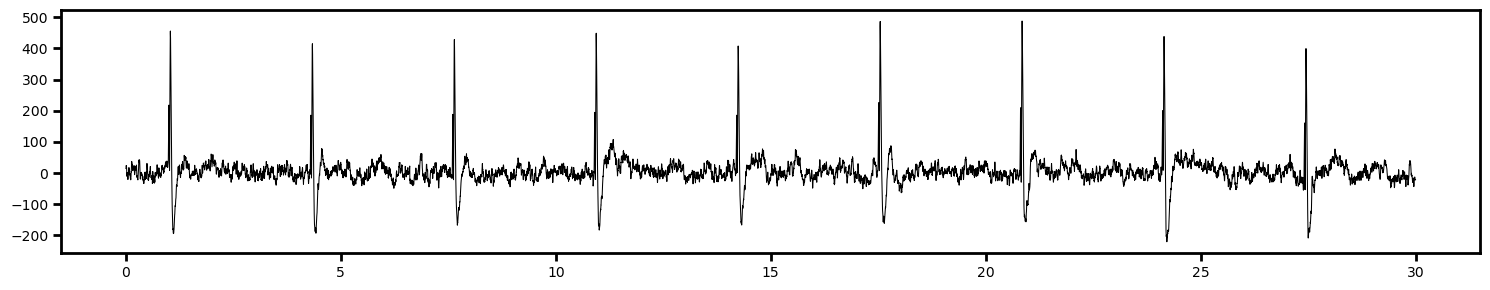

In [20]:
ex = epochs_ccep_post.copy().pick([target_channel]).get_data()
nf = []; 
for i in range(ex.shape[0]):
    nf.append(ex[i, 0, :])
nf = np.hstack(nf)
nf = nf[1651*2:]

plt.figure(figsize=(15, 3)); ax=plt.subplot(111)
plt.plot(np.arange(15000)/float(500), nf[:15000], color='k', linewidth=0.75);
#plt.vlines(np.arange(500, 15000, 1651)/float(500), ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linestyle='--', color='k')
plt.tight_layout()
#plt.savefig('./figs/S25_248_example_single_trials_post.pdf')

### Analyze spectral response across participants
Same as above, with some adjustments for parallelization and memory optimization. 

In [4]:
def process_subject_block(subject, params):

    import numpy as np
    import pandas as pd
    import re
    from scipy.stats import zscore
    
    try:
        # Load Data
        fn_prefix = f'../derivatives/pulse_labels/{subject}'
        epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
        epochs_trigger = epochs_trigger.crop(tmin=-1, tmax=2.3)                         # to ensure uniform time windows across all subjects
        
        local_data = []
        
        for tbs_block in ['iTBS1', 'iTBS2', 'iTBS3']:
        
            # Filter Intensity
            if params['intensity'] == 'High':
                epochs_trigger = epochs_trigger['~(block.str.contains("Low"))'].pick_types(seeg=True, exclude=[])
            elif params['intensity'] == 'Low':
                epochs_trigger = epochs_trigger['~(block.str.contains("High"))'].pick_types(seeg=True, exclude=[])
            else:
                epochs_trigger = epochs_trigger.pick_types(seeg=True, exclude=[])
            
            # Get events metadata
            meta = epochs_trigger.metadata
            all_targets = meta['stim_target'].unique()
            m_block = meta[meta['block'] == tbs_block]
            
            for targ in all_targets:
                m = m_block[m_block['stim_target'] == targ]
                if len(m) == 0: 
                    print('***No events found for this target/block combination***')
                    continue
            
                # Get single-pulse (CCEP) data
                pre_q =  f'(block.str.contains("Pre{tbs_block}") & (stim_target.str.contains("{targ}")))'
                post_q = f'(block.str.contains("Post{tbs_block}") & (stim_target.str.contains("{targ}")))'
                baseline_q = f'(block.str.contains("PreiTBS1|Baseline") & (stim_target.str.contains("{targ}")))'    
                epochs_ccep_pre = epochs_trigger[pre_q]
                epochs_ccep_post = epochs_trigger[post_q]
                epochs_ccep_baseline = epochs_trigger[baseline_q]

                # Check to see if we have data for this block/target
                if len(epochs_ccep_pre)==0:
                    print('***No events found for this target/block combination***')
                    continue
            
                # Identify target lead
                target_chans, target_idxs = exclude_target_lead(epochs_ccep_pre)
            
                # Reject outlier epochs and channels
                bad_epochs_pre, bad_epochs_post, reject_channels = reject_outlier_epochs(epochs_ccep_pre, epochs_ccep_post, outlier_threshold=params['outlier_threshold'])
                bad_epochs_dict = {'bad_epochs_pre': bad_epochs_pre, 'bad_epochs_post': bad_epochs_post}
                epochs_ccep_pre.info['bads'] += reject_channels
                epochs_ccep_post.info['bads'] += reject_channels
                epochs_ccep_baseline.info['bads'] += reject_channels
            
                results = {'subject': subject, 'block': tbs_block, 'target': targ}
        
                # Rank top channels by z-scored CCEP
                epochs_z_baseline = epochs_ccep_baseline.copy().apply_function(zscore_epoch, times=epochs_ccep_baseline.times, baseline=(-0.2, 0)).average()
                df_ptp, _, _ = rank_channels_by_ptp(epochs_z_baseline, n_top=10, n_bottom=10)
                top_chans = df_ptp[df_ptp['ptp_value']>3]['channel'].tolist()
                bottom_chans = df_ptp['channel'].tail(len(top_chans)).tolist()
                if len(top_chans)<0:
                    print('***No significant CCEPs found!***: '+subject+', '+targ+', '+tbs_block)
                    continue
                
                for cond, subset in [('pre', epochs_ccep_pre), ('post', epochs_ccep_post)]:
            
                    # Get CCEPs
                    epochs_z = subset.copy().apply_function(zscore_epoch, times=subset.times, baseline=(-0.2, 0))
                    evoked_z = epochs_z.average()
                    
                    # Compute time-frequency representation
                    tfr = subset.compute_tfr(method=params['method'], freqs=params['freq_range'],
                                     n_cycles=params['n_cycles'], picks=subset.ch_names, verbose=False)
                    
                    # Baseline correct (doing this manually, as MNE's baseline correct behavior is not easy to understand)
                    bs = tfr.copy().crop(tmin=params['spectral_baseline_start'], tmax=params['spectral_baseline_end'])
                    bs_avg_time = np.nanmean(np.log10(bs.data), axis=3)
                    subtract_array = np.tile(bs_avg_time[..., np.newaxis], (1, 1, 1, tfr.data.shape[3]))
                    tfr_corrected = np.log10(tfr.data)-subtract_array
            
                    # Remove outlier events
                    bad_epochs = bad_epochs_dict['bad_epochs_'+cond]
                    for idx, epoch_id in enumerate(bad_epochs):
                        tfr_corrected[epoch_id, idx, :, :] = np.nan 
    
                    # Window the data across time dimension for better averaging and such
                    tfr_times = tfr.times
                    win_starts = np.arange(params['tmin_plot'], params['tmax_plot'] - params['win_dur'], params['win_step'])
                    win_centers = win_starts + (params['win_dur'] / 2)
                    
                    def get_win_data(raw):
                        out = np.zeros((raw.shape[0], raw.shape[1], len(params['freq_range']), len(win_starts)))
                        for w_idx, start in enumerate(win_starts):
                            t_m = (tfr_times >= start) & (tfr_times < start + params['win_dur'])
                            out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
                        return out
                    
                    tfr_win = get_win_data(tfr_corrected)
            
                    # Save results
                    results[f'{cond}_tfr'] = np.nanmean(tfr_win, axis=2)  # average over frequencies due to memory issues
                    results[f'{cond}_ccep'] = evoked_z.data
                    results['lead_channels'] = target_chans
                    results['channels'] = tfr.ch_names
                    results['top_chans'] = top_chans
                    results['bottom_chans'] = bottom_chans
                    results['bad_chans'] = reject_channels  # newly-identified bad channels based on epoch exclusions
                    results['ptp_baseline'] = df_ptp
        
                local_data.append(results)
    except Exception as e:
        print(f"Error in {subject}-{tbs_block}: {e}")
    
    return local_data

#### Parallel processing

In [5]:
# HFA: np.logspace(np.log10(75), np.log10(180), 6), n_cycles=6  + spectral baseline of -0.6 to -0.1
# Theta: np.logspace(np.log10(4), np.log10(8), 4), n_cycles=2   + spectral baseline of -0.75 to -0.25

if __name__ == '__main__':
    # Package all your spectral/analysis parameters
    analysis_params = {
        'method': 'multitaper',
        'n_cycles': 2,
        'spectral_baseline_start': -0.75,
        'spectral_baseline_end': -0.25,
        'freq_range': np.logspace(np.log10(4), np.log10(8), 4),
        'outlier_threshold': 5,
        'intensity': 'High',
        'win_dur': 0.2,
        'win_step': 0.05, 
        'tmin_plot': -1.0, 
        'tmax_plot': 2.3
    }

    # Use a Pool with a sensible number of workers (start with 4-6 to avoid RAM crashes)
    with mp.Pool(processes=3) as pool:
        # Use starmap to pass (subject, block, params) to the worker
        result_lists = pool.starmap(process_subject_block, [(s, analysis_params) for s in subject_ids])

    # Flatten the list of lists into one DataFrame
    flat_results = [item for sublist in result_lists for item in sublist]
    subject_data = pd.DataFrame(flat_results)

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:11: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:11: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:11: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:11: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-e

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:101: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:107: RuntimeWarning: Mean of empty slice
  results[f'{cond}_tfr'] = np.nanmean(tfr_win, axis=2)  # average over frequencies due to memory issues
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:101: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:107: RuntimeWarning: Mean of empty slice
  results[f'{cond}_tfr'] = np.nanmean(tfr_win, axis=2)  # average over frequencies due to memory issues
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:101: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/f

***No events found for this target/block combination***
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:101: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:107: RuntimeWarning: Mean of empty slice
  results[f'{cond}_tfr'] = np.nanmean(tfr_win, axis=2)  # average over frequencies due to memory issues


...

***No events found for this target/block combination***
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
***No events found for this target/block combination***
***No events found for this target/block combination***
***No events found for this target/block combination***
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
***No events found for this target/block combination***
***No events found for this target/block combination***
***No events found for this target/block combination***


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:101: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:107: RuntimeWarning: Mean of empty slice
  results[f'{cond}_tfr'] = np.nanmean(tfr_win, axis=2)  # average over frequencies due to memory issues
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:101: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:107: RuntimeWarning: Mean of empty slice
  results[f'{cond}_tfr'] = np.nanmean(tfr_win, axis=2)  # average over frequencies due to memory issues
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:101: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/f

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
***No events found for this target/block combination***
***No events found for this target/block combination***
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
***No events found for this target/block combination***
***No events found for this target/block combination***
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:101: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:107: RuntimeWarning: Mean of empty slice
  results[f'{cond}_tfr'] = np.nanmean(tfr_win, axis=2)  # average over frequencies due to memory issues
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:101: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:107: RuntimeWarning: Mean of empty slice
  results[f'{cond}_tfr'] = np.nanmean(tfr_win, axis=2)  # average over frequencies due to memory issues
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2671145505.py:101: RuntimeWarning: Mean of empty slice
  out[:, :, :, w_idx] = np.nanmean(raw[:, :, :, t_m], axis=3)
/var/f

Error in S26_264-iTBS1: epochs.Modifying data of epochs() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.


**Reorganize data into one row per electrode**

In [6]:
expanded_data = []

for idx, row in subject_data.iterrows():
    ch_names = row['channels']
    df_ptp = row['ptp_baseline']
    
    # Pre-calculate sets for faster membership testing
    lead_set = set(row['lead_channels'])
    top_set = set(row['top_chans'])
    bottom_set = set(row['bottom_chans'])
    bad_set = set(row['bad_chans'])
    
    for ch_idx, ch_name in enumerate(ch_names):
        # Extract data for this specific channel
        # TFRs are (trials, channels, time) -> we want (trials, time)
        # CCEPs are (channels, time) -> we want (time,)

        # Extract baseline peak to peak amplitude
        ptp_amp = df_ptp[df_ptp['channel'].str.contains(ch_name, case=False)].iloc[0]['ptp_value']
        
        node_data = {
            'subject': row['subject'],
            'block': row['block'],
            'target': row['target'],
            'channel': ch_name,
            'pre_tfr': row['pre_tfr'][:, ch_idx, :],
            'post_tfr': row['post_tfr'][:, ch_idx, :],
            'pre_ccep': row['pre_ccep'][ch_idx, :],
            'post_ccep': row['post_ccep'][ch_idx, :],
            'baseline_ptp': ptp_amp,
            # Boolean Flags
            'is_lead': ch_name in lead_set,
            'is_top': ch_name in top_set,
            'is_bottom': ch_name in bottom_set, 
            'is_bad': ch_name in bad_set,
        }
        
        expanded_data.append(node_data)

# Create the new electrode-level DataFrame
df_electrodes = pd.DataFrame(expanded_data)

# Display the first few rows to verify
print(f"Original rows: {len(subject_data)} | New electrode rows: {len(df_electrodes)}")
df_electrodes.head()

Original rows: 52 | New electrode rows: 8820


,subject,block,target,channel,pre_tfr,post_tfr,pre_ccep,post_ccep,baseline_ptp,is_lead,is_top,is_bottom,is_bad
0,S25_245,iTBS1,LAMF8-LAMF9,LAIF1-LAIF2,"[[0.025711124820442653, 0.03870459027697221, -...","[[-0.9683838620141225, -0.7377269922184225, -0...","[0.0013006395026926906, 0.0010999287236214664,...","[-0.23333504157916654, -0.2692810818653741, -0...",2.544760,False,False,False,False
1,S25_245,iTBS1,LAMF8-LAMF9,LAIF2-LAIF3,"[[-0.043074660497364116, -0.011357789499736598...","[[-0.6791024798043009, -0.49194556733725553, -...","[-0.06257259260992859, -0.07420699651903039, -...","[-0.048325223173895995, -0.0332078779602372, -...",4.684273,False,True,False,False
2,S25_245,iTBS1,LAMF8-LAMF9,LAIF3-LAIF4,"[[-0.08150696425670137, 0.013833098203797065, ...","[[-0.3102442545127171, -0.2151237195471997, -0...","[0.14635526848177377, 0.1820165388030143, 0.21...","[0.5637753749911718, 0.5602618920623798, 0.569...",3.099897,False,True,False,False
3,S25_245,iTBS1,LAMF8-LAMF9,LAIF4-LAIF5,"[[0.011827804484976053, -0.01516973187704564, ...","[[-0.128203106346793, -0.0032443219264933322, ...","[0.312920645026473, 0.27383476409206603, 0.252...","[-0.42713782826561136, -0.38735879862278777, -...",1.799863,False,False,False,False
4,S25_245,iTBS1,LAMF8-LAMF9,LAIF5-LAIF6,"[[-0.23029249880731834, -0.026122531631813765,...","[[0.16164105935987824, 0.17608871761657796, 0....","[0.909566804609052, 0.9225048603921101, 0.9318...","[0.5279284496653182, 0.5417121302983018, 0.547...",3.654345,False,True,False,False


**Get electrode-level stats and average across subjects**

Note that channel-level shuffled t-statistics are not used in the manuscript. 

In [7]:
%matplotlib inline

# Load some sample data to get data object information
subject = 'S25_245'
fn_prefix = f'../derivatives/pulse_labels/{subject}'
epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
epochs_trigger = epochs_trigger.crop(tmin=-1, tmax=2.3) 

tfr_times = epochs_trigger.times
win_starts = np.arange(analysis_params['tmin_plot'], analysis_params['tmax_plot'] - analysis_params['win_dur'], analysis_params['win_step'])
win_centers = win_starts + (analysis_params['win_dur'] / 2)

from scipy.stats import ttest_ind
from tqdm import tqdm

def compute_subject_stats(df, n_perms=10):
    """
    Computes t-stats and permutation p-values for each row (subject/block).
    """
    t_stats_list = []
    p_vals_list = []
    z_stats_list = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Permuting Subjects"):
        pre = row['pre_tfr']   # (trials, time)
        post = row['post_tfr'] # (trials, time)
        
        # 1. Observed T-Statistic (Post vs Pre)
        # Positive t-stat = Increase after TBS; Negative = Decrease
        t_obs, _ = ttest_ind(post, pre, axis=0, nan_policy='omit')
        
        # # 2. Permutation Test
        # combined = np.concatenate([pre, post], axis=0)
        # n_pre = pre.shape[0]
        
        # max_t_null = []
        # for _ in range(n_perms):
        #     # Shuffle trial labels
        #     shuffled = np.random.permutation(combined)
        #     t_null, _ = ttest_ind(shuffled[:n_pre], shuffled[n_pre:], axis=0, nan_policy='omit')
        #     max_t_null.append(t_null)
            
        # # Calculate p-values (two-tailed)
        # max_t_null = np.array(max_t_null)
        # p_vals = np.mean(np.abs(max_t_null) >= np.abs(t_obs), axis=0)

        # # Calculate z-score
        # mu_ = np.mean(max_t_null); std_ = np.std(max_t_null)
        # z_score = (t_obs-mu_)/std_
        
        t_stats_list.append(t_obs)
        p_vals_list.append(np.nan)
        z_stats_list.append(np.nan)
        
    df['t_stats'] = t_stats_list
    df['p_vals'] = p_vals_list
    df['z_stats'] = z_stats_list
    return df

# Run the computation
df_electrodes = compute_subject_stats(df_electrodes)


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2534263902.py:6: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2534263902.py:6: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
Permuting Subjects: 100%|████████████████████████████████████████████████████████| 8820/8820 [02:45<00:00, 53.26it/s]


#### Add localization information
Associates channel-level effects with localization information include MNI coordinates, anatomical label, and distance from stimulation site. 

In [8]:
import sys
sys.path.insert(0, '../lib/')  # add path to custom library
from codebase import get_elec_dists, bipolarize_dists
import bisect

df_electrodes['distance'] = np.nan
df_electrodes['quartile'] = np.nan
df_electrodes['stim_region'] =  np.nan
df_electrodes['channel_region'] = np.nan
df_electrodes['stim_MNI'] = np.nan; df_electrodes['stim_MNI'] = df_electrodes['stim_MNI'].astype(object)
df_electrodes['channel_MNI'] = np.nan; df_electrodes['channel_MNI'] = df_electrodes['channel_MNI'].astype(object)
df_electrodes['jp_stim_1'] = np.nan; df_electrodes['jp_stim_2'] = np.nan
df_electrodes['jp_channel_1'] = np.nan; df_electrodes['jp_channel_2'] = np.nan

for subject in subject_ids[:]:

    # Load localization information
    loc = pd.read_csv('../data/'+subject+'/'+subject+'_loc.csv')

    # Find anatomy column (can take many different names)
    jp_cols = [c_name for c_name in loc.columns if ((('JP' in str(c_name).upper()) | ('JOSEF' in str(c_name).upper())) & ('NOTES' not in str(c_name).upper()))]

    # Load the MNE object to get channel information
    fn_prefix = '../derivatives/pulse_labels/'+subject
    epochs_trigger = mne.read_epochs(fn_prefix+'_trigs-epo.fif')
        
    # Loop through blocks of the experiment
    for stim_target in df_electrodes[df_electrodes['subject'].str.contains(subject)]['target'].unique():
        
        # Get electrode distances from the stim target
        elec_dists = get_elec_dists(loc, stim_target)
        bp_dists = bipolarize_dists(epochs_trigger.ch_names, elec_dists, loc)
        tmp = np.array(list(bp_dists.values()))
        quartiles = np.quantile(tmp[np.isfinite(tmp)], [0.25, 0.5, 0.75])    

        # Region Labeling
        targ_parts = stim_target.split('-')
        r1 = loc[loc['FS_label'].astype(str).str.contains(targ_parts[0], case=False)]['Desikan_Killiany'].iloc[0]
        r2 = loc[loc['FS_label'].astype(str).str.contains(targ_parts[1], case=False)]['Desikan_Killiany'].iloc[0]
        mni1 = np.array(loc[loc['FS_label'].astype(str).str.contains(targ_parts[0], case=False)][['MNI_coord_1', 'MNI_coord_2', 'MNI_coord_3']])
        mni2 = np.array(loc[loc['FS_label'].astype(str).str.contains(targ_parts[1], case=False)][['MNI_coord_1', 'MNI_coord_2', 'MNI_coord_3']])
        stimcoord = np.nanmean(np.vstack([mni1, mni2]), axis=0)

        jp_stim_target_labels = []
        for col_name in jp_cols:
            j1 = loc[loc['FS_label'].astype(str).str.contains(targ_parts[0], case=False)][col_name].iloc[0]
            j2 = loc[loc['FS_label'].astype(str).str.contains(targ_parts[1], case=False)][col_name].iloc[0]
            jp_stim_target_labels.append(f"{j1}_{j2}")

        # Loop through relevant indices and add information
        indices = df_electrodes[(df_electrodes['subject']==subject) & (df_electrodes['target'].str.contains(stim_target, case=False))].index
        if len(indices)==0: continue;

        for idx in indices:
            chan = df_electrodes.loc[idx]['channel']
            dist = bp_dists[chan]
            if np.isnan(dist):
                dist_quartile = np.nan
            else:
                dist_quartile = bisect.bisect(quartiles, dist)

            # Get channel region
            if '-' in chan:
                chan_parts = chan.split('-')
                try:
                    c1 = loc[loc['FS_label'].astype(str).str.contains(chan_parts[0], case=False)]['Desikan_Killiany'].iloc[0]
                    c2 = loc[loc['FS_label'].astype(str).str.contains(chan_parts[1], case=False)]['Desikan_Killiany'].iloc[0]
                    mni1 = np.array(loc[loc['FS_label'].astype(str).str.contains(chan_parts[0], case=False)][['MNI_coord_1', 'MNI_coord_2', 'MNI_coord_3']])
                    mni2 = np.array(loc[loc['FS_label'].astype(str).str.contains(chan_parts[1], case=False)][['MNI_coord_1', 'MNI_coord_2', 'MNI_coord_3']])
                    chancoord = np.nanmean(np.vstack([mni1, mni2]), axis=0)
    
                    jp_chan_labels = []
                    for col_name in jp_cols:
                        j1 = loc[loc['FS_label'].astype(str).str.contains(chan_parts[0], case=False)][col_name].iloc[0]
                        j2 = loc[loc['FS_label'].astype(str).str.contains(chan_parts[1], case=False)][col_name].iloc[0]
                        jp_chan_labels.append(f"{j1}_{j2}")
                except:
                    # very rarely, a channel is in the EEG structure but *not* in the loc file and must be handled
                    df_electrodes.at[idx, 'is_bad'] = True
                    continue
            else:
                continue

            # Add data
            df_electrodes.at[idx, 'distance'] = dist
            df_electrodes.at[idx, 'quartile'] = dist_quartile
            df_electrodes.at[idx, 'stim_region'] =  f"{r1}_{r2}"
            df_electrodes.at[idx, 'channel_region'] = f"{c1}_{c2}"
            df_electrodes.at[idx, 'stim_MNI'] = stimcoord
            df_electrodes.at[idx, 'channel_MNI'] = chancoord
            for colidx in range(len(jp_cols)):
                idx_str = str(colidx+1)
                df_electrodes.at[idx, 'jp_stim_'+idx_str] = jp_stim_target_labels[colidx]
                df_electrodes.at[idx, 'jp_channel_'+idx_str] = jp_chan_labels[colidx]


Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S25_245_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2300.00 ms
        0 CTF compensation matrices available
Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S25_245_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2300.00 ms
        0 CTF compensation matrices available


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2547421063.py:25: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(fn_prefix+'_trigs-epo.fif')


Adding metadata with 6 columns
2526 matching events found
No baseline correction applied
0 projection items activated


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2547421063.py:25: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(fn_prefix+'_trigs-epo.fif')
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2547421063.py:87: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'rostralmiddlefrontal_rostralmiddlefrontal' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_electrodes.at[idx, 'stim_region'] =  f"{r1}_{r2}"
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2547421063.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown_rostralmiddlefrontal' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_electrodes.at[idx, 'channe

Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S23_214_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2300.00 ms
        0 CTF compensation matrices available
Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S23_214_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2300.00 ms
        0 CTF compensation matrices available


...

Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S25_258_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2500.00 ms
        0 CTF compensation matrices available
Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S25_258_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2500.00 ms
        0 CTF compensation matrices available
Adding metadata with 6 columns
3140 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S25_120c_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2300.00 ms
        0 CTF compensation matrices available
Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S25_120c_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2300.00 ms
        0 

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2547421063.py:25: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(fn_prefix+'_trigs-epo.fif')


Adding metadata with 6 columns
3068 matching events found
No baseline correction applied
0 projection items activated


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_88694/2547421063.py:25: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(fn_prefix+'_trigs-epo.fif')


Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S26_263_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2300.00 ms
        0 CTF compensation matrices available
Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S26_263_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2300.00 ms
        0 CTF compensation matrices available
Adding metadata with 6 columns
3125 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S26_264_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2300.00 ms
        0 CTF compensation matrices available
Reading /Users/esolomon/scripts/Stanford_eTBS/notebooks/../derivatives/pulse_labels/S26_264_trigs-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2300.00 ms
        0 CT

In [9]:
# Add PTP data to the DataFrame: In case we're curious about PTP at the level of each block
df_electrodes['ptp'] = np.nan
st_ = 0.05; fin_ = 0.3

for idx, row in df_electrodes.iterrows():
    win_mask = (epochs_trigger.times>st_) & (epochs_trigger.times<fin_)
    d = row['pre_ccep'][win_mask]  # Note that here we're getting PTP from the pre-block data, not the original baseline as done in the initial processing code
    ptp = np.ptp(d, axis=0)
    df_electrodes.at[idx, 'ptp'] = ptp

In [10]:
df_electrodes.to_pickle('./outputs/iTBS_multitaper_Shamtheta_onlyHigh_0.2dur_0.05step_outliersExcluded.pkl')

In [510]:
import pandas as pd
import numpy as np


def aggregate_channels_by_subject(df_slice, sig_alpha=0.01):
    """
    Averages pre_tfr and post_tfr arrays across channels within each subject/block.
    Input: A slice of df_electrodes (rows = channels).
    Output: A new DataFrame (rows = subjects) with averaged arrays.
    """
    aggregated_data = []

    # Group by subject and block to keep the experimental conditions distinct
    grouped = df_slice.groupby(['subject', 'block', 'target'])

    for (subject, block, target), group in grouped:
        # 1. Stack all channel arrays into a 3D volume: (channels, trials, time)
        # We use .values to get the list of arrays from the column
        pre_stack = np.stack(group['pre_tfr'].values)
        post_stack = np.stack(group['post_tfr'].values)
        tstat_stack = np.stack(group['t_stats'].values)
        p_stack = np.stack(group['p_vals'].values)

        # 2. Average across the channel dimension (axis 0)
        # This results in a (trials, time) array representing the "Subject Average"
        pre_subject_mean = np.nanmean(pre_stack, axis=0)
        post_subject_mean = np.nanmean(post_stack, axis=0)
        t_mean = np.nanmean(tstat_stack, axis=0)
        p_sum = np.nansum(p_stack<sig_alpha, axis=0)

        # 3. Store result with metadata
        aggregated_data.append({
            'subject': subject,
            'block': block,
            'target': target,
            'pre_tfr': pre_subject_mean,
            'post_tfr': post_subject_mean,
            't_stats': t_mean,
            'sig_count': p_sum,
            'n_channels_averaged': len(group)
        })

    return pd.DataFrame(aggregated_data)

# Define the data subset
plot_subset = df_electrodes[
                            (df_electrodes['stim_region'].str.contains('')) &
                            (df_electrodes['channel_region'].str.contains('', case=False)) & 
                            (df_electrodes['is_bad'] == False) &
                            (df_electrodes['is_top'] == True) & 
                            (df_electrodes['is_lead'] == False) 
                            #(df_electrodes['distance']>100) 
                            ]
                           
# Example Usage:
df_subject_level = aggregate_channels_by_subject(plot_subset)

15 subjects/targets included.


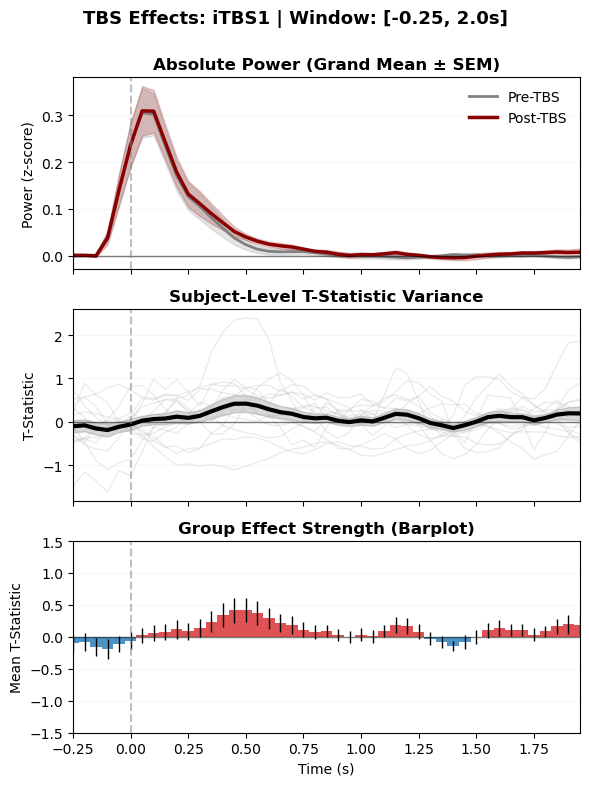

In [513]:
## import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, ttest_1samp
from mne.stats import fdr_correction

def plot_subject_tstats_clean(df, block_name, time_vector, time_window=None, ylim_=(-1, 1)):
    """
    Plots a 3-tier vertical stack with trial-averaging per subject.
    1. Absolute Power Overlay (Pre vs Post Grand Means)
    2. T-statistic variance (Individual traces + Grand Mean)
    3. Effect Magnitude Barplot (FDR corrected)
    """
    # 1. Filter Block
    subset = df[df['block'] == block_name]
    if subset.empty:
        print(f"No data for block: {block_name}")
        return
    print(f"{len(subset)} subjects/targets included.")

    # 2. Apply Time Window Mask
    if time_window is not None:
        t_mask = (time_vector >= time_window[0]) & (time_vector <= time_window[1])
        plot_time = time_vector[t_mask]
    else:
        t_mask = np.ones(len(time_vector), dtype=bool)
        plot_time = time_vector

    # 3. Extract and Average Trials per Subject
    # We use a list comprehension to mean over trials (axis 0) for each subject first
    # This handles the unequal trial counts problem.
    pre_sub_means = [np.nanmean(val, axis=0)[t_mask] for val in subset['pre_tfr'].values]
    post_sub_means = [np.nanmean(val, axis=0)[t_mask] for val in subset['post_tfr'].values]
    
    # T-stats are usually already 1D per subject (Electrode/Window), 
    # but we mask them here too.
    t_stats_raw = np.stack([val[t_mask] for val in subset['t_stats'].values])
    
    # Now we can safely stack the subject means
    pre_group_stack = np.stack(pre_sub_means)
    post_group_stack = np.stack(post_sub_means)
    
    # 4. Calculate Group Metrics
    mean_pre, sem_pre = np.nanmean(pre_group_stack, axis=0), sem(pre_group_stack, axis=0, nan_policy='omit')
    mean_post, sem_post = np.nanmean(post_group_stack, axis=0), sem(post_group_stack, axis=0, nan_policy='omit')
    
    grand_t_mean = np.nanmean(t_stats_raw, axis=0)
    grand_t_sem = sem(t_stats_raw, axis=0, nan_policy='omit')
    
    # Stats: 1-sample t-test vs 0 on the T-stats
    t_vals, p_vals = ttest_1samp(t_stats_raw, 0, axis=0, nan_policy='omit')
    sig_mask, _ = fdr_correction(p_vals, alpha=0.05)
    
    # 5. Plotting (3 Rows, 1 Column)
    fig, axes = plt.subplots(3, 1, figsize=(6, 8.5), sharex=True)
    bar_width = np.diff(plot_time)[0] if len(plot_time) > 1 else 0.01

    # --- TOP SUBPLOT: Absolute Power Overlay ---
    ax0 = axes[0]
    ax0.plot(plot_time, mean_pre, color='gray', linewidth=2, label='Pre-TBS')
    ax0.fill_between(plot_time, mean_pre-sem_pre, mean_pre+sem_pre, color='gray', alpha=0.2)
    ax0.plot(plot_time, mean_post, color='darkred', linewidth=2.5, label='Post-TBS')
    ax0.fill_between(plot_time, mean_post-sem_post, mean_post+sem_post, color='darkred', alpha=0.2)
    ax0.set_title('Absolute Power (Grand Mean ± SEM)', fontweight='bold')
    ax0.set_ylabel('Power (z-score)')
    ax0.legend(frameon=False, loc='upper right')

    # --- MIDDLE SUBPLOT: T-Stat Variance ---
    ax1 = axes[1]
    for t_course in t_stats_raw:
        ax1.plot(plot_time, t_course, color='silver', alpha=0.3, linewidth=1)
    ax1.plot(plot_time, grand_t_mean, color='black', linewidth=3, label='Grand Mean T')
    ax1.fill_between(plot_time, grand_t_mean - grand_t_sem, grand_t_mean + grand_t_sem, 
                     color='black', alpha=0.15)
    ax1.set_title('Subject-Level T-Statistic Variance', fontweight='bold')
    ax1.set_ylabel('T-Statistic')

    # --- BOTTOM SUBPLOT: Barplot + Significance ---
    ax2 = axes[2]
    colors = ['#d62728' if val >= 0 else '#1f77b4' for val in grand_t_mean]
    ax2.bar(plot_time, grand_t_mean, width=bar_width, color=colors, alpha=0.8, 
            yerr=grand_t_sem, error_kw={'ecolor': 'black', 'lw': 1, 'capsize': 0})
    
    if np.any(sig_mask):
        y_lim = ax2.get_ylim()
        y_pos = y_lim[1] * 0.9 if y_lim[1] > 0 else 0.5
        ax2.scatter(plot_time[sig_mask], [y_pos] * np.sum(sig_mask), 
                    color='black', marker='*', s=35, label='FDR $p < 0.05$')
    ax2.set_title('Group Effect Strength (Barplot)', fontweight='bold')
    ax2.set_ylabel('Mean T-Statistic')
    ax2.set_ylim(ylim_[0], ylim_[1])

    # 6. Universal Formatting
    for ax in axes:
        
        ax.axhline(0, color='black', linewidth=1, alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, axis='y', alpha=0.1)
        ax.set_xlim([plot_time[0], plot_time[-1]])

    axes[2].set_xlabel('Time (s)')
    window_str = f"[{time_window[0]}, {time_window[1]}s]" if time_window else "Full Epoch"
    plt.suptitle(f'TBS Effects: {block_name} | Window: {window_str}', fontsize=13, fontweight='bold', y=0.95)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Execution
target_window = [-0.25, 2.0] 
plot_subject_tstats_clean(df_subject_level, 'iTBS1', win_centers, time_window=target_window, ylim_=(-1.5, 1.5))

#### Plot differences across TBS blocks

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_1456/2454507902.py:13: RuntimeWarning: Mean of empty slice
  out[:, w_idx] = np.nanmean(raw_2d[:, t_mask], axis=1)


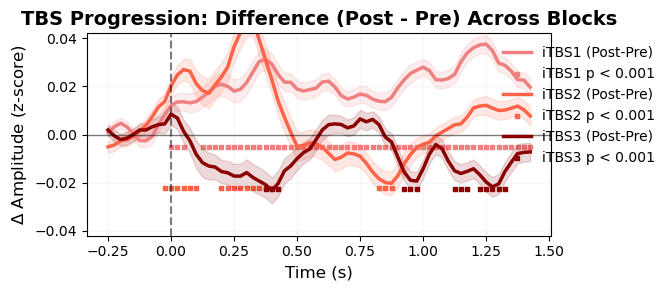

In [80]:
# Include all blocks for a specific electrode type or subject
progression_subset = df_electrodes[(df_electrodes['is_top'] == True) & 
                                   (df_electrodes['is_bad'] == False) & 
                                   (df_electrodes['is_lead'] == False)]
sig_alpha = 0.001 

def plot_tbs_progression(df, time_vector, ylim_=(-0.042, 0.042)):
    blocks = ['iTBS1', 'iTBS2', 'iTBS3']
    # A gradient of reds: light coral, tomato, dark red
    colors = ['#F08080', '#FF6347', '#8B0000']
    
    fig, ax = plt.subplots(figsize=(7, 3))
    
    all_sig_masks = []
    
    for i, (block, color) in enumerate(zip(blocks, colors)):
        # Filter for the specific block
        block_df = df[df['block'] == block]
        
        if block_df.empty:
            print(f"Skipping {block}: No data found in subset.")
            continue
            
        # 1. Reuse your existing stats function
        win_centers, pre_data, post_data, p_vals = get_windowed_stats(block_df, time_vector)
        
        # 2. Calculate Difference and SEM
        diff_data = post_data - pre_data
        mean_diff = np.nanmean(diff_data, axis=0)
        sem_diff = sem(diff_data, axis=0, nan_policy='omit')
        
        # 3. Plot the Difference Curve
        ax.plot(win_centers, mean_diff, color=color, label=f'{block} (Post-Pre)', linewidth=2.5)
        ax.fill_between(win_centers, mean_diff - sem_diff, mean_diff + sem_diff, 
                        color=color, alpha=0.15)
        
        # 4. Significance Markers (with vertical offset for each block)
        pbool, pcorr = fdr_correction(p_vals, sig_alpha)
        sig_mask = pbool
        if np.any(sig_mask):
            # Calculate a unique Y-position for this block's markers
            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min
            # Place markers at the bottom, stacked 3% apart
            y_pos = y_min + (y_range * (0.05 + (i * 0.03)))
            
            ax.scatter(win_centers[sig_mask], [y_pos] * np.sum(sig_mask), 
                        color=color, marker='s', s=12, label=f'{block} p < {sig_alpha}')

    # Global Formatting
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax.set_title('TBS Progression: Difference (Post - Pre) Across Blocks', fontweight='bold', fontsize=14)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('$\Delta$ Amplitude (z-score)', fontsize=12)
    ax.set_ylim(ylim_[0], ylim_[1])
    
    # Clean up legend (optional: only show one "p < 0.05" label if it gets crowded)
    ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.25, 1))
    ax.grid(True, alpha=0.1)
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
plot_tbs_progression(progression_subset, epochs_ccep_pre.times)

#### See if there's a significant effect of iTBS in general, averaging across blocks

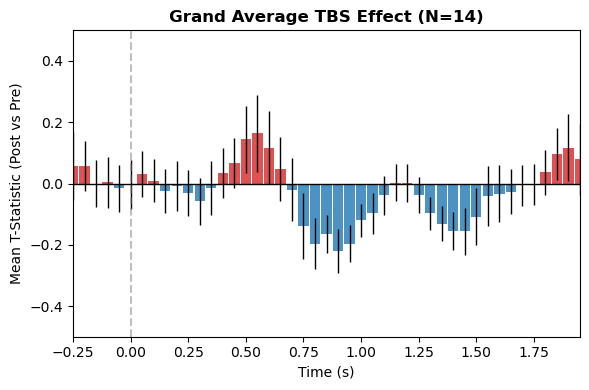

In [493]:
def plot_tbs_grand_average_bars(df, time_vector, blocks=['iTBS1', 'iTBS2', 'iTBS3'], time_window=None, ylim_=(-1, 1)):
    """
    Collapses TBS blocks within-subject and plots only the Grand-Average 
    Effect Strength barplot with FDR correction.
    """
    from scipy.stats import sem, ttest_1samp
    from statsmodels.stats.multitest import fdrcorrection as fdr_correction

    # 1. Filter for the requested blocks
    subset = df[df['block'].isin(blocks)]
    if subset.empty:
        print(f"No data for blocks: {blocks}")
        return

    # 2. Within-Subject Averaging (Manual to avoid pandas agg errors)
    subjects = subset['subject'].unique()
    sub_t_stats = []

    for sub in subjects:
        # Get all blocks for this subject
        sub_data = subset[subset['subject'] == sub]
        # Stack all t_stat arrays for this subject and mean them
        stacked_blocks = np.stack(sub_data['t_stats'].values) 
        sub_t_stats.append(np.nanmean(stacked_blocks, axis=0))
    
    t_stats_collapsed = np.stack(sub_t_stats) # Shape: (Subjects, Time)

    # 3. Apply Time Window Mask
    if time_window is not None:
        t_mask = (time_vector >= time_window[0]) & (time_vector <= time_window[1])
        plot_time = time_vector[t_mask]
        t_stats_final = t_stats_collapsed[:, t_mask]
    else:
        plot_time = time_vector
        t_stats_final = t_stats_collapsed

    # 4. Group Statistics
    grand_t_mean = np.nanmean(t_stats_final, axis=0)
    grand_t_sem = sem(t_stats_final, axis=0, nan_policy='omit')
    
    # 1-sample t-test vs 0
    _, p_vals = ttest_1samp(t_stats_final, 0, axis=0, nan_policy='omit')
    sig_mask, _ = fdr_correction(p_vals, alpha=0.05)
    
    # 5. Plotting (Single Barplot)
    fig, ax = plt.subplots(figsize=(6, 4))
    bar_width = np.diff(plot_time)[0] if len(plot_time) > 1 else 0.05

    colors = ['#d62728' if val >= 0 else '#1f77b4' for val in grand_t_mean]
    
    ax.bar(plot_time, grand_t_mean, width=bar_width*0.9, color=colors, alpha=0.8, 
            yerr=grand_t_sem, error_kw={'ecolor': 'black', 'lw': 1, 'capsize': 0})
    
    # Significance stars
    if np.any(sig_mask):
        # Place stars slightly above the highest error bar
        y_max = np.max(grand_t_mean + grand_t_sem)
        y_pos = y_max + (0.05 * abs(y_max)) if y_max > 0 else 0.2
        ax.scatter(plot_time[sig_mask], [y_pos] * np.sum(sig_mask), 
                    color='black', marker='*', s=30, label='FDR $p < 0.05$')

    # Formatting
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'Grand Average TBS Effect (N={len(subjects)})', fontweight='bold')
    ax.set_ylabel('Mean T-Statistic (Post vs Pre)')
    ax.set_xlabel('Time (s)')
    ax.set_ylim(ylim_)
    ax.set_xlim([plot_time[0], plot_time[-1]])
    
    plt.tight_layout()
    plt.show()

# Usage
target_window = [-0.25, 2.0]
plot_tbs_grand_average_bars(df_subject_level, win_centers, time_window=target_window, ylim_=(-0.5, 0.5))


#### Is the PTP CCEP strength correlated with spectral plasticity response?

In [570]:
# Add PTP data to the DataFrame
df_electrodes['ptp'] = np.nan
st_ = 0.05; fin_ = 0.3

for idx, row in df_electrodes.iterrows():
    win_mask = (epochs_trigger.times>st_) & (epochs_trigger.times<fin_)
    d = row['pre_ccep'][win_mask]  # Note that here we're getting PTP from the pre-block data, not the original baseline as done in the initial processing code
    ptp = np.ptp(d, axis=0)
    df_electrodes.at[idx, 'ptp'] = ptp

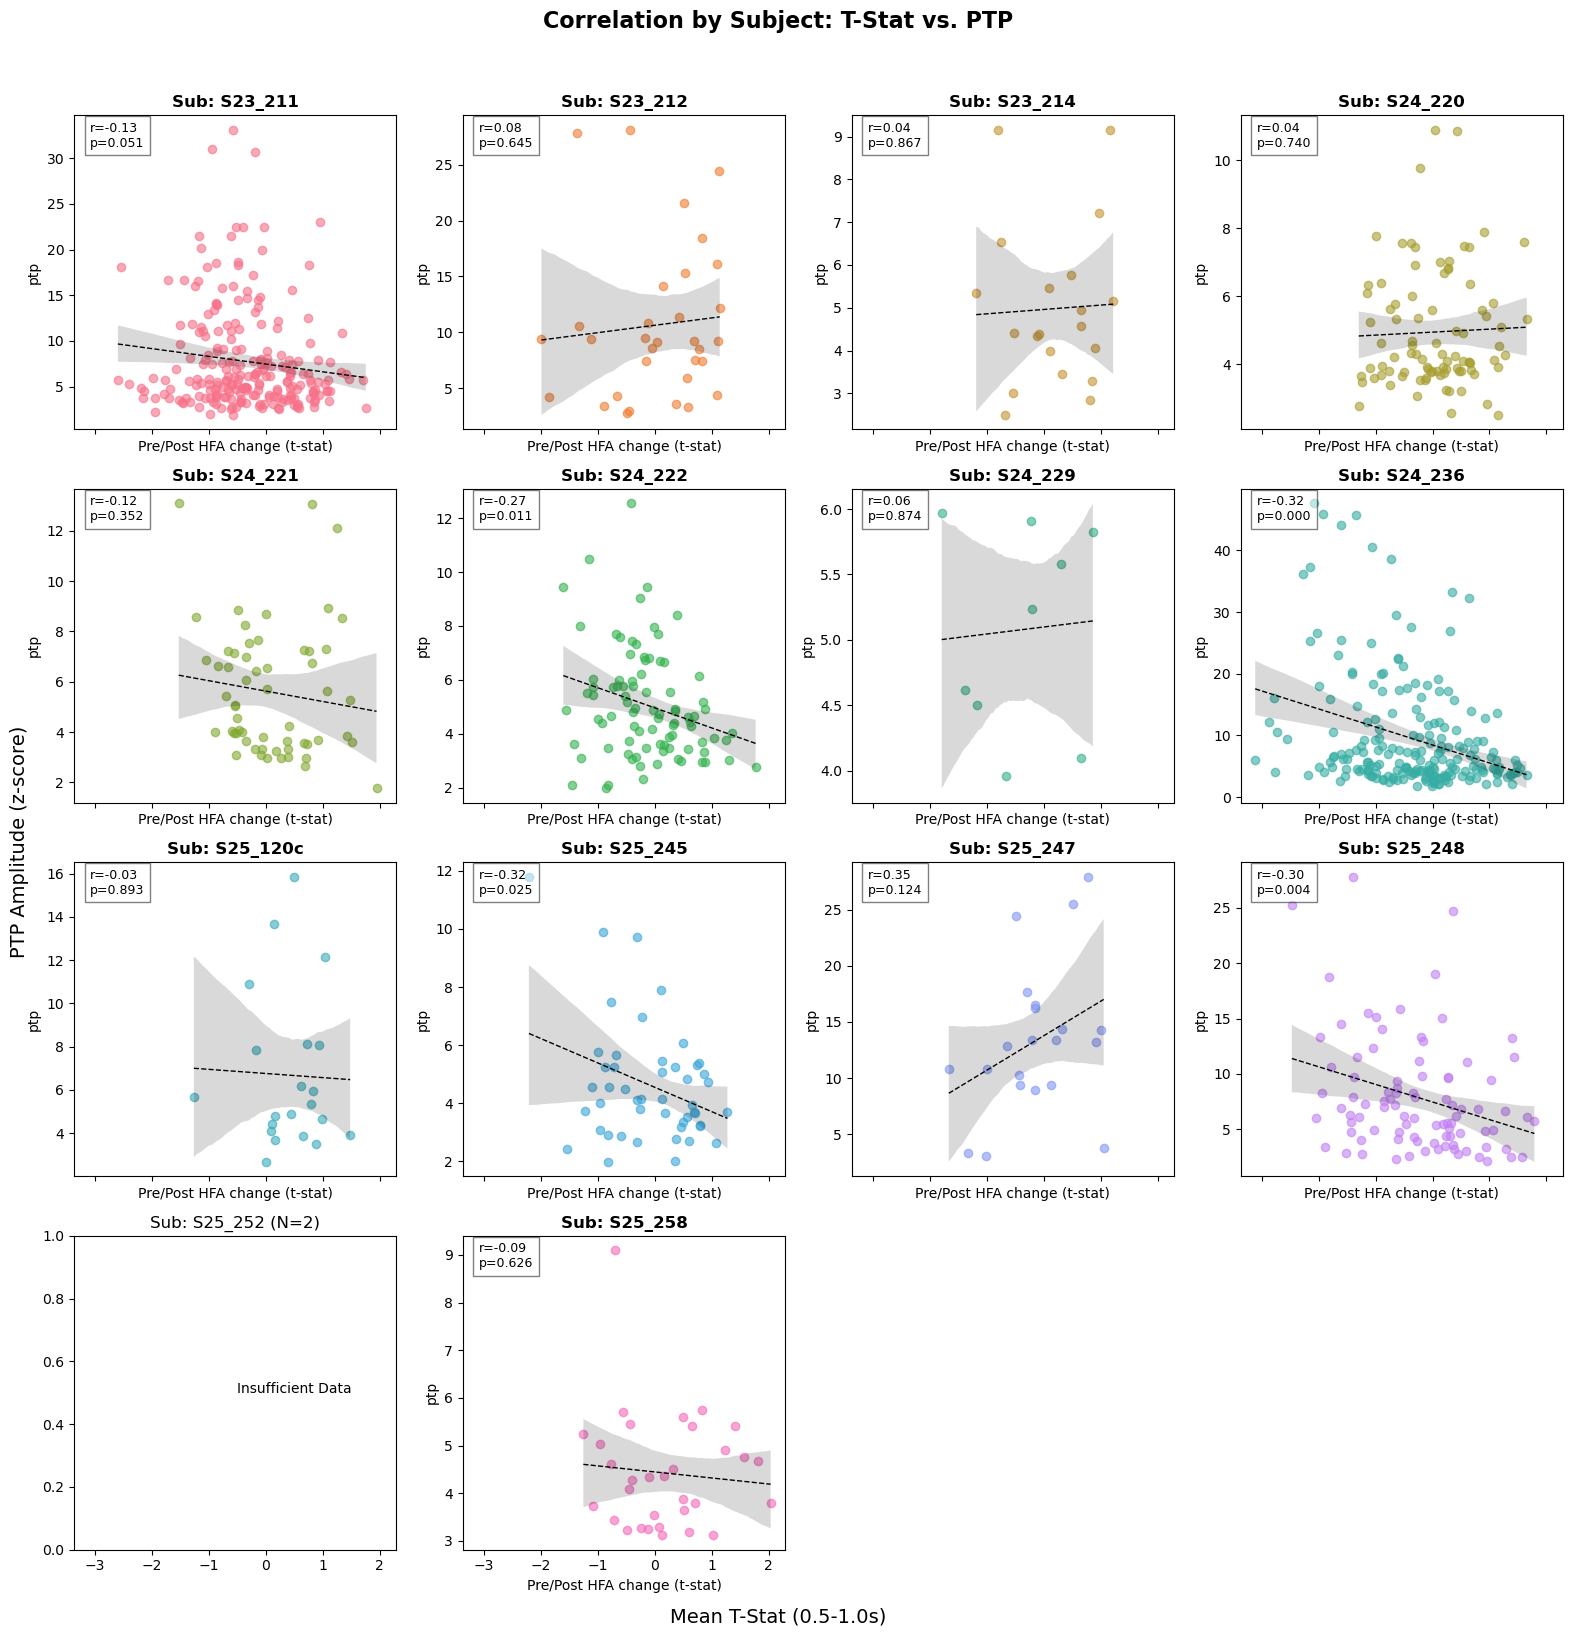

In [681]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- User Parameters ---
t_start, t_end = 0.5, 1.0  # The time window for the N100, for example
cols_per_row = 4             # How many subjects per row
# -----------------------

def plot_subject_correlations(df, win_centers):
    # 1. Data Prep
    df = df.copy()
    t_mask = (win_centers >= t_start) & (win_centers <= t_end)
    df['mean_window_t'] = [np.nanmean(ts[t_mask]) for ts in df['t_stats'].values]
    
    subjects = sorted(df['subject'].unique())
    n_subs = len(subjects)
    n_rows = (n_subs + cols_per_row - 1) // cols_per_row
    
    # 2. Setup Figure
    fig, axes = plt.subplots(n_rows, cols_per_row, 
                             figsize=(4 * cols_per_row, 4 * n_rows), 
                             sharex=True, sharey=False)
    axes = axes.flatten() # Flatten for easy iteration
    
    # Define a color palette for variety
    palette = sns.color_palette("husl", n_subs)
    
    # 3. Iterate through Subjects
    for i, sub in enumerate(subjects):
        ax = axes[i]
        sub_df = df[df['subject'] == sub].dropna(subset=['mean_window_t', 'ptp'])
        
        if len(sub_df) > 2:
            # Calculate stats
            r, p = pearsonr(sub_df['mean_window_t'], sub_df['ptp'])
            
            # Plot
            sns.regplot(data=sub_df, x='mean_window_t', y='ptp', 
                        ax=ax, color=palette[i], scatter_kws={'alpha':0.6},
                        line_kws={'color': 'black', 'linestyle': '--', 'linewidth': 1})
            
            # Annotate Subplot
            ax.set_title(f'Sub: {sub}', fontweight='bold')
            ax.text(0.05, 0.9, f'r={r:.2f}\np={p:.3f}', transform=ax.transAxes, 
                    fontsize=9, bbox=dict(facecolor='white', alpha=0.5))
            ax.set_xlabel('Pre/Post HFA change (t-stat)')
        else:
            ax.text(0.5, 0.5, 'Insufficient Data', ha='center')
            ax.set_title(f'Sub: {sub} (N={len(sub_df)})')

    # 4. Clean up Empty Subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    # Global Labels
    fig.supxlabel(f'Mean T-Stat ({t_start}-{t_end}s)', fontsize=14)
    fig.supylabel('PTP Amplitude (z-score)', fontsize=14)
    plt.suptitle(f'Correlation by Subject: T-Stat vs. PTP', fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()

# Execution
# Assuming df_electrodes is already filtered for the block you want
plot_subset = df_electrodes[
                            (df_electrodes['block'].str.contains('')) & 
                            (df_electrodes['is_bad'] == False) &
                            (df_electrodes['is_lead'] == False) &
                            (df_electrodes['is_top'] == True)
                            
                            ]

plot_subject_correlations(plot_subset, win_centers)

In [682]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

def run_repeated_measures_lme(df, win_centers, t_start=0.5, t_end=1.0):
    df_lme = df.copy()
    
    # 1. Prepare predictor
    t_mask = (win_centers >= t_start) & (win_centers <= t_end)
    df_lme['mean_window_t'] = [np.nanmean(ts[t_mask]) for ts in df_lme['t_stats'].values]
    
    # 2. Standardize continuous variables
    df_lme['ptp_z'] = (df_lme['ptp'] - df_lme['ptp'].mean()) / df_lme['ptp'].std()
    df_lme['t_stat_z'] = (df_lme['mean_window_t'] - df_lme['mean_window_t'].mean()) / df_lme['mean_window_t'].std()
    
    # 3. Create a unique ID for each channel within each subject
    # This allows the model to realize that 'LINA1' in Sub1 is a different physical
    # location than 'LINA1' in Sub2.
    df_lme['sub_chan'] = df_lme['subject'].astype(str) + "_" + df_lme['channel'].astype(str)

    # 4. Define the Model
    # Formula: ptp_z predicted by T-stat, the Block, and their interaction (*)
    # C(block) tells statsmodels to treat iTBS1, 2, and 3 as distinct categories.
    formula = "t_stat_z ~ ptp_z + C(block)"
    
    # Random Effects: 
    # groups="subject" handles the top-level variance.
    # vc_formula={"sub_chan": "0 + C(sub_chan)"} adds a random intercept for 
    # every specific electrode to account for the repeated measures over blocks.
    model = smf.mixedlm(formula, df_lme, 
                        groups=df_lme["subject"], 
                        vc_formula={"sub_chan": "0 + C(sub_chan)"})
    
    result = model.fit()
    
    print("--- Repeated Measures LME Results ---")
    print(result.summary())
    
    return result

# Execution
lme_repeated_results = run_repeated_measures_lme(plot_subset, win_centers)

--- Repeated Measures LME Results ---
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  t_stat_z  
No. Observations:   953      Method:              REML      
No. Groups:         14       Scale:               0.8432    
Min. group size:    2        Log-Likelihood:      -1317.0292
Max. group size:    231      Converged:           Yes       
Mean group size:    68.1                                    
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.072    0.051  1.406 0.160 -0.028  0.173
C(block)[T.iTBS2] -0.315    0.073 -4.347 0.000 -0.458 -0.173
C(block)[T.iTBS3]  0.096    0.073  1.328 0.184 -0.046  0.238
ptp_z             -0.225    0.034 -6.702 0.000 -0.291 -0.159
sub_chan Var       0.079    0.039                           



#### Break down analysis by individual channels, looking for ones with predominant negative/positive responses, instead of averaging

In [423]:
from copy import copy

sig_elecs = []
begin_stats = 24 #which window to start looking for significant effect

# Select relevant subset
plot_subset = df_electrodes[
                            (df_electrodes['stim_region'].str.contains('')) &
                            (df_electrodes['channel_region'].str.contains('', case=False)) & 
                            (df_electrodes['is_bad'] == False) &
                            (df_electrodes['is_top'] == True) & 
                            (df_electrodes['is_lead'] == False)]

for idx, row in subset.iterrows(): 

    # Only interested in timepoints after the pulse
    d = copy(row['p_vals']<0.05); d = d.astype(int)[begin_stats:]  # don't want pre-stim values
    psign = np.sign(row['t_stats'])[begin_stats:]
    d = psign*d

    # Only look at positives/negatives right now
    d[d<0] = 0
    d = np.abs(d)
    
    # Find stretches of significance of sufficient length (e.g. 3) 
    diff_arr = np.diff(np.hstack(([0], d, [0])))
    ones_ =  np.where(diff_arr==1)[0]
    negs_ = np.where(diff_arr==-1)[0]
    zipped = list(zip(ones_, negs_))
    stretch_length = np.array([i[1]-i[0] for i in zipped])

    # Check if they meet our criteria
    if np.sum(stretch_length>3)>0:
        sig_elecs.append(idx)
    else:
        continue

iTBS1_subset = aggregate_channels_by_subject(df_electrodes.loc[sig_elecs])

In [419]:
# Get the same elecs for iTBS2, iTBS3
# Each electrode-subject pair is unique
subject_electrode_pairs = []
for idx in sig_elecs:
    subject_electrode_pairs.append((df_electrodes.loc[idx]['subject'], df_electrodes.loc[idx]['channel']))

iTBS2_subset = []
for sp in subject_electrode_pairs:
    selec = df_electrodes[(df_electrodes['block']=='iTBS2') & 
        (df_electrodes['subject']==sp[0]) & 
        (df_electrodes['channel']==sp[1])]
    if len(selec)==0:
        continue
    iTBS2_subset.append(selec)
iTBS2_subset = pd.concat(iTBS2_subset, ignore_index=True)
iTBS2_subset = aggregate_channels_by_subject(iTBS2_subset)

iTBS3_subset = []
for sp in subject_electrode_pairs:
    selec = df_electrodes[(df_electrodes['block']=='iTBS3') & 
        (df_electrodes['subject']==sp[0]) & 
        (df_electrodes['channel']==sp[1])]
    if len(selec)==0:
        continue
    iTBS3_subset.append(selec)
iTBS3_subset = pd.concat(iTBS3_subset, ignore_index=True)
iTBS3_subset = aggregate_channels_by_subject(iTBS3_subset)


7 subjects/targets included.


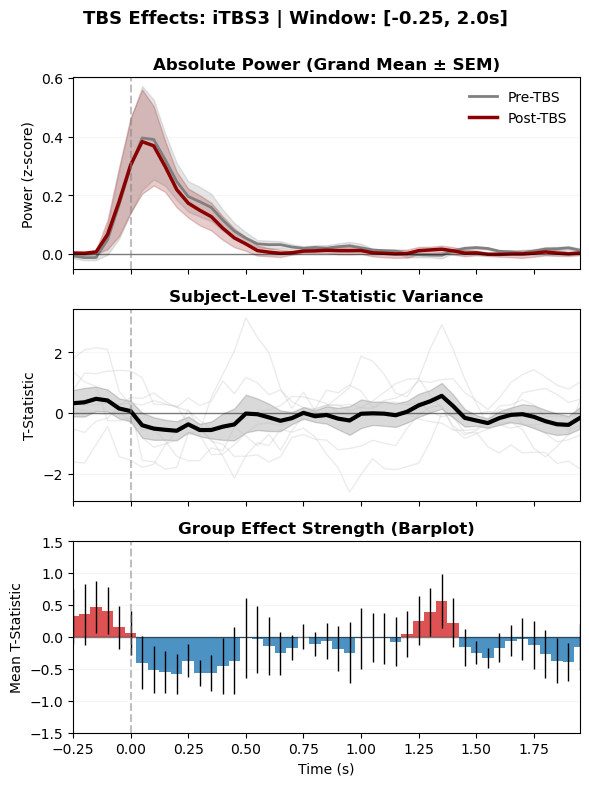

In [422]:
target_window = [-0.25, 2.0] 
plot_subject_tstats_clean(iTBS3_subset, 'iTBS3', win_centers, time_window=target_window, ylim_=(-1.5, 1.5))

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_1456/2454507902.py:13: RuntimeWarning: Mean of empty slice
  out[:, w_idx] = np.nanmean(raw_2d[:, t_mask], axis=1)


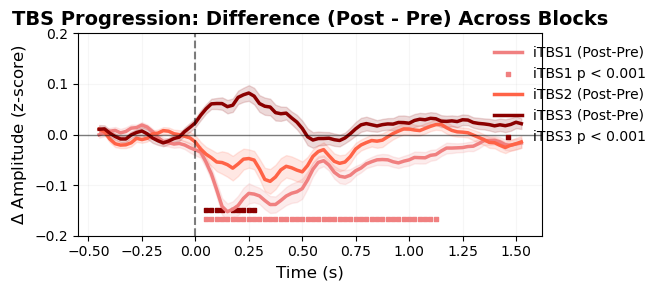

In [50]:
plot_tbs_progression(pd.concat([iTBS1_subset, iTBS2_subset, iTBS3_subset]), epochs_ccep_pre.times, ylim_=(-0.20, 0.20))

#### Add location information